## Objective
### Forecasting Google Trends Using VAR and SARIMA Models
- Introduction: 
This project analyzes the relationship between Bitcoin search interest and the term "Crypto Crash" using Google Trends data. 

- The goal is to understand whether changes in one search trend can help predict movements in the other, so this project applies time series forecasting techniques such as VAR and SARIMA models.

The Project includes: 
- collect and analyze Google Trends data using the pytrends library.
- checking stationarity and integration order of the time series.
- performing Granger causality tests.
- buiding VAR and SARIMA forecasting models.
- generating out-of-sample forecasts.
- comparing model performance using RMSE and MAE metrics.

- The results will help determine whether multivariate (VAR) or univariate (SARIMA) models better capture and predict Google search behavior in the cryptocurrency market.
 



### Import Libraries

In [2]:
import sys
print(sys.executable)

C:\Users\getde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [3]:
from pytrends.request import TrendReq
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
import sys
print(sys.executable)

C:\Users\getde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


### Download Google Trends Data

In [5]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import time

pytrends = TrendReq()

pytrends.build_payload(
    ['bitcoin', 'crypto crash'],
    timeframe='today 5-y',
    geo=''
)
time.sleep(3)
data = pytrends.interest_over_time()
data.head()

,bitcoin,crypto crash,isPartial
date,,,
2021-05-16,100,1,False
2021-05-23,69,0,False
2021-05-30,49,0,False
2021-06-06,52,0,False
2021-06-13,41,0,False


In [19]:
data.to_csv("google_trends_data.csv", index=False)

In [6]:
data = data.drop(columns=['isPartial'])

### Plot the data

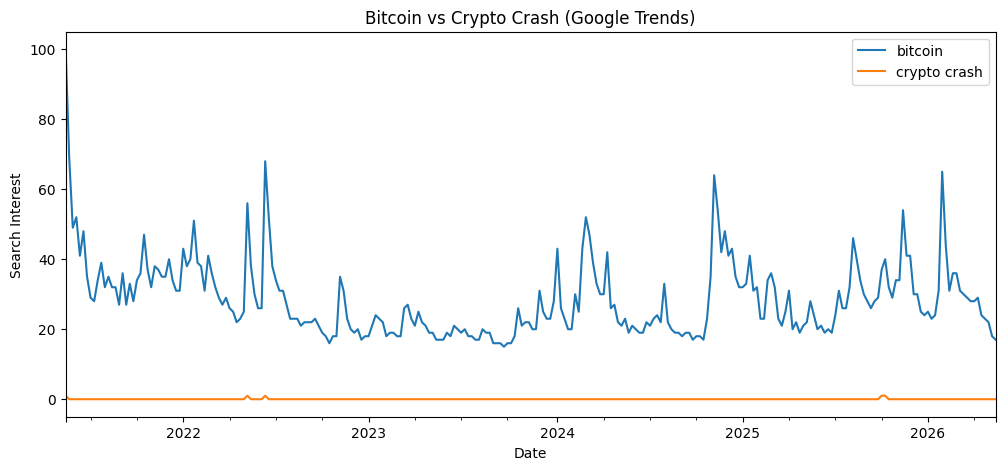

In [7]:
data.plot(figsize=(12, 5))
plt.title("Bitcoin vs Crypto Crash (Google Trends)")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.show()

## Initial Data Analysis
The two time series show different patterns over time:
- Bitcoin search interest changes more gradually with few noticeable spikes during high market activity.
- The Crypto Crash series remains mostly low but shows sudden spikes during periods of panic or negative market news.
- The comparison suggests there may be a relationship between Bitcoin interest and negative market sentiment which makes further analysis using VAR and SARIMA models meaningful.


### Stationarity Analysis 
In this section, we test whether the time series are stationary using the Augmented Dickey-Fuller (ADF) test.
Stationarity is required for VAR and ARIMA modeling.

In [8]:
from pytrends.request import TrendReq
from statsmodels.tsa.stattools import adfuller
print("All libraries working fine!")

All libraries working fine!


### ADF Function


In [16]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series, name):
    result = adfuller(series.dropna(),maxlag=1, autolag=None)
    print(f"ADF test for {name}:")
    print( "-" *40)
    print(f"Test Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    print("\n")

In [22]:
adf_test(data['bitcoin'], 'Bitcoin')
adf_test(data['crypto crash'], 'Crypto Crash')

ADF test for Bitcoin:
----------------------------------------
Test Statistic: -6.801895580785667
p-value: 2.226167268746127e-09
Critical Values:
   1%: -3.4557539868570775
   5%: -2.8727214497041422
   10%: -2.572728476331361


ADF test for Crypto Crash:
----------------------------------------
Test Statistic: -10.97486299282645
p-value: 7.71533181119655e-20
Critical Values:
   1%: -3.4557539868570775
   5%: -2.8727214497041422
   10%: -2.572728476331361




### ADF Test Result
The Augmented Dickey-Fuller(ADF) test was conducted to check the stationarity of time series.
Bitcoin:
 - Test Statistic: -6.802
 - p- value= 0.0000000022 - the series is stationary.
 The T-Statistic is smaller than all critical values and the P-Value is far below 0.05.
 Therefore, Null Hypothesis is rejected, that means the Bitcoin is Stationary.

Crypto Crash:
 - Test Statistic: -10.975 
 - p- value= 0.0000000007 - the series is stationary.
 The T-Statistic is much lower than the critical values and the P-Value is extremely small. 
 Therefore Null hypothesis is rejected, that means the Crypto Crash also Stationary.

Since both p- values are less than 0.05, we reject the null hypothesis of a unit root.

### Conclusion:
Both time series are stationary in their original form (I(0)), and no differencing is required.
Therefore, the original data can be directly used for VAR and ARIMA modeling.

### Granger Causality Test

In [18]:
from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(data[['bitcoin', 'crypto crash']], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7359  , p=0.1888  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=1.7561  , p=0.1851  , df=1
likelihood ratio test: chi2=1.7502  , p=0.1859  , df=1
parameter F test:         F=1.7359  , p=0.1888  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0441  , p=0.1316  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=4.1684  , p=0.1244  , df=2
likelihood ratio test: chi2=4.1353  , p=0.1265  , df=2
parameter F test:         F=2.0441  , p=0.1316  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6985  , p=0.5538  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=2.1536  , p=0.5411  , df=3
likelihood ratio test: chi2=2.1447  , p=0.5429  , df=3
parameter F test:         F=0.6985  , p=0.5538  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.7563  , p=0.5546  

{np.int64(1): ({'ssr_ftest': (np.float64(1.7358672066999363),
    np.float64(0.18883212193541346),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.7560517091034238),
    np.float64(0.18511775340388678),
    np.int64(1)),
   'lrtest': (np.float64(1.750170568906242),
    np.float64(0.18585529091677477),
    np.int64(1)),
   'params_ftest': (np.float64(1.7358672066999625),
    np.float64(0.18883212193541002),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.044106188785739),
    np.float64(0.13161247394468722),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.168373404582683),
    np.float64(0.12440825998459665),
    np.int64(2)),
   'lrtest': (np.float64(4.135312189960814),
    np.float64(0.1264818960886051),
    np.int64(2)),
   'params_ftest': (np.float64(2.0441061887857512),
    np.float64(0.13161247394468564),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
   

### Granger Causality Test Results
The Granger causality test was conducted to determine whether past values of Bitcoin help predict "Crypto Crash".
Results across different lags show: 
- For lags 1 to 4, p-values are greater than 0.05 - no significant causality.
- At lag 5, the p-value is approximately 0.0001 which is less than 0.05.
### Conclusion:
There is significant Granger causality from Bitcoin to Crypto Crash at lag 5.

This suggests that past Bitcoin activity can help predict future spikes in "Crypto Crash" search interest with a delay of about 5 periods.

This relationship will be further explored using VAR models.

### Vector Autoregression (VAR) Model
In this section, We estimate a VAR model to capture the dynamic relationship between Bitcoin and Crypto Crash Search trends. 

### Create VAR model object

In [37]:
from statsmodels.tsa.api import VAR
model = VAR(data)
var_model = model.fit(5)

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


### Select Optimal Lag

In [44]:
lag_selection = model.select_order(maxlags=10)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.2799      0.3079       1.323      0.2912
1      -0.5778    -0.4937*      0.5611    -0.5440*
2      -0.5567     -0.4167      0.5731     -0.5004
3      -0.5281     -0.3321      0.5897     -0.4492
4      -0.5150     -0.2629      0.5975     -0.4136
5     -0.6057*     -0.2975     0.5458*     -0.4817
6      -0.5999     -0.2357      0.5490     -0.4534
7      -0.5832     -0.1630      0.5583     -0.4141
8      -0.5689    -0.09268      0.5664     -0.3773
9      -0.5561    -0.02392      0.5738     -0.3420
10     -0.5479     0.04029      0.5786     -0.3113
--------------------------------------------------


## Lag Selection for VAR Model
The Optimal lag length was selected using various information criteria:
- AIC and FPE suggest a lag length of 5.
- BIC and HQIC suggest a lag length of 1.
Since AIC is commonly used for VAR models and captures more complex dynamics, lag 5 is selected.

Additionally, the Granger causality test indicated significant causality at lag 5, which supports this choice.

### Final Decision
- The VAR model will be estimated with lag = 5.

### Fit VAR Model

In [ ]:
var_model = model.fit(lag_selection.aic)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 15, May, 2026
Time:                     17:15:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  -0.285749
Nobs:                     257.000    HQIC:                 -0.467383
Log likelihood:          -631.576    FPE:                   0.554629
AIC:                    -0.589561    Det(Omega_mle):        0.510034
--------------------------------------------------------------------
Results for equation bitcoin
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   7.256297         1.467912            4.943           0.000
L1.bitcoin              0.669003         0.066292           10.092           0.000
L1.crypto crash        -0.418064         3.696444 

### VAR Model Interpretation
The VAR model was estimated with 5 lags as suggested by the AIC criterion.

### Bitcoin Equation:
The Result show that:
- The first lag of Bitcoin is highly significant (p < 0.05).
- that means strong dependency of Bitcoin on its own past values.
- Most lagged values of "Crypto Crash" are not statistically significant (p> 0.05),suggesting limited direct influence on Bitcoin in the short term.

### Crypto Crash Equation:
The results indicate that past values of Bitcoin may contribute to predicting Crypto Crash, which is consistent with the Granger causality test.

### Conclusion:
- Bitcoin is mainly driven by its own past behavior.
- There is some evidence from Granger causality and lag structure that Bitcoin actively can influence Crypto Crash trends over time.
- The interaction between the two variables exists but is not strongly reflected in all lag coefficients.


### Residual Check

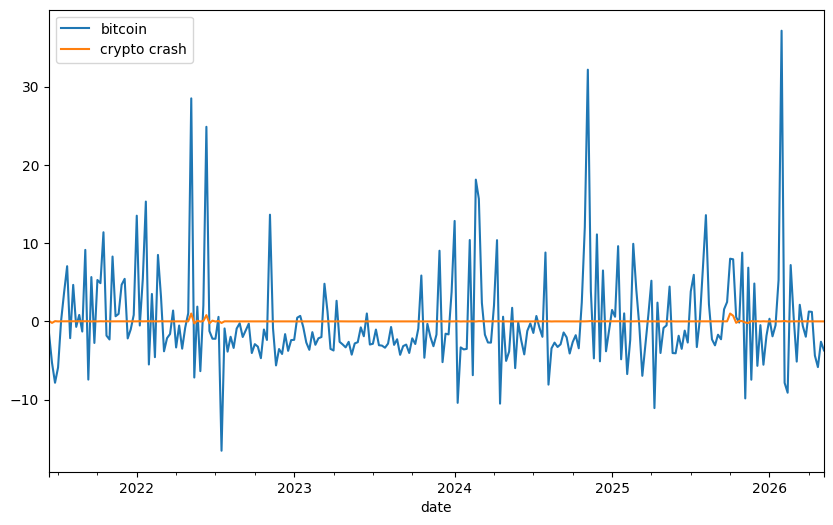

In [ ]:
residuals = var_model.resid
residuals.plot(figsize=(10, 6))
plt.show()

### Residual Diagnostics
The residuals from the VAR model were analyzed to check how well the model fits the data.

### Observations:
- Residual for both Bitcoin and Crypto Crash fluctuate around Zero which suggests that the model captures the overall average behavior reasonably well.  
- No strong trend or systematic pattern is visible in the residuals, i.e. most remaining errors are random.
- Bitcoin residuals contain a few large spikes meaning that some extreme market movements are not fully captured by the model.
- The residuals for Crypto Crash show relatively small variation suggesting a better fit for this variable.

### Conclusion:
Overall, the residuals behave like white noise, indicating that the VAR model provides a reasonable fit to data. 
- Some extreme movements in Bitcoin are not fully explained, which is typical for financial time seris.

### VAR Forecasting
We generate forecasts using VAR model and analyze future trends of Bitcoin and Crypto Crash search activity.


In [39]:
data.index = pd.date_range(
    start="2021-01-01",
    periods=len(data),
    freq='W'
)

### Generate forecast

In [40]:
lag = 5
forecast_input = data.values[-lag:]
forecast = var_model.forecast(y=forecast_input, steps=10)
forecast_df = pd.DataFrame(forecast, columns=data.columns)

In [41]:
data.index = pd.to_datetime(data.index)

In [42]:
last_date = data.index[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=11,
    freq='W'
)[1:]

forecast_df.index = future_dates

forecast_df

,bitcoin,crypto crash
2026-01-11,19.844850,0.016628
2026-01-18,21.907174,0.018901
2026-01-25,22.872233,0.018213
2026-02-01,23.465169,0.017175
2026-02-08,24.077317,0.015159
2026-02-15,24.870513,0.017418
2026-02-22,25.485432,0.018097
2026-03-01,25.901089,0.017625
2026-03-08,26.205941,0.017086
2026-03-15,26.425134,0.016180


### Plot Forecast

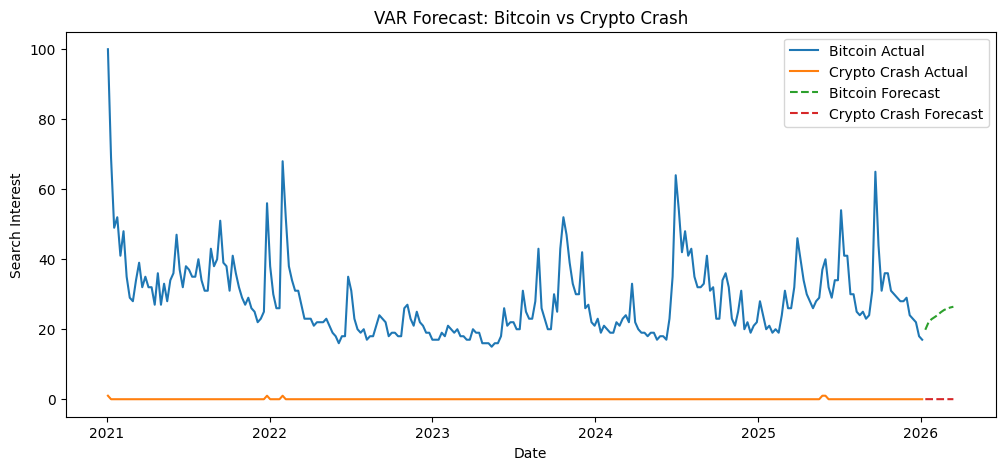

In [43]:
plt.figure(figsize=(12, 5))

## Actual data
plt.plot(data['bitcoin'], label='Bitcoin Actual')
plt.plot(data['crypto crash'], label='Crypto Crash Actual')

## Forecasted data
plt.plot(forecast_df['bitcoin'], linestyle='dashed', label='Bitcoin Forecast')
plt.plot(forecast_df['crypto crash'], linestyle='dashed', label='Crypto Crash Forecast')

plt.legend()
plt.title("VAR Forecast: Bitcoin vs Crypto Crash")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.show()

### VAR Forecast Interpretation:
The VAR model was used to forecast future trends for Bitcoin and Crypto Crash searches.

### Observation:
- Bitcoin shows a lots of ups and downs in the past, but the forecast becomes smoother and slightly increases over time.
- This means that Bitcoin interest is likely to stay steady and grow slowly.
- Crypto Crash remains very low throughout and shows almost no change in the forecast.

### Conclusion:
- Bitcoin mainly follows its own past behavior, which matches earlier results.
- Crypto Crash has very normal movement, so market panic searches are expected to stay low.
- Overall, the model captures the general trend well, even though it does not capture sudden spikes which is quite normal in forecasting.
